# Running k=11

Since the merge between the datasets created a lot of columns (over 2,000), it's necesary to reduce the dimensions of the dataset with PCA before running the k-means algorithm.

## Import Statements

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances_argmin_min, silhouette_samples
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
import folium

from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import ipywidgets as widgets
from ipywidgets import interact, interactive

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [2]:
X_ = np.load("scaled-df.npy")
df = pd.read_csv("bofedales-clean.csv").drop("Unnamed: 0", axis=1)
df.shape

(2372, 2294)

The K-Means algorithm will run on the dataset in PC space.

## Find the Optimal Amount of Groups for K-Means

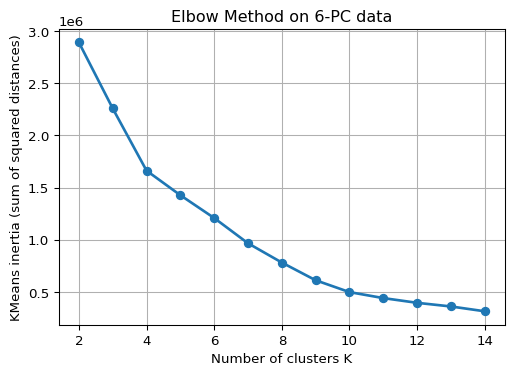

In [3]:
inertias = []
K_candidates = list(range(2, 15))

for k in K_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_candidates, inertias, marker='o', lw=2)
plt.xlabel("Number of clusters K")
plt.ylabel("KMeans inertia (sum of squared distances)")
plt.title("Elbow Method on 6-PC data")
plt.grid(True)
plt.show()

In [4]:
def kmeans_metrics(X, k_min=2, k_max=15, random_state=42):
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(X)

        rows.append(
            {
                "k": k,
                "silhouette": silhouette_score(X, labels),
                "davies_bouldin": davies_bouldin_score(X, labels),
                "calinski_harabasz": calinski_harabasz_score(X, labels),
            }
        )

    return pd.DataFrame(rows)


results = kmeans_metrics(X_, k_min=2, k_max=14)
print(results)

# Highlight the “best” K by each metric
best_k_sil = results.loc[results["silhouette"].idxmax(), "k"]
best_k_db  = results.loc[results["davies_bouldin"].idxmin(), "k"]
best_k_ch  = results.loc[results["calinski_harabasz"].idxmax(), "k"]

print(
    f"\nBest-by-metric suggestions:\n"
    f"  • Silhouette         ➜ K = {best_k_sil}\n"
    f"  • Davies-Bouldin (↓) ➜ K = {best_k_db}\n"
    f"  • Calinski-Harabasz  ➜ K = {best_k_ch}"
)

     k  silhouette  davies_bouldin  calinski_harabasz
0    2    0.452759        1.039208        1694.929931
1    3    0.452236        1.119121        1408.231170
2    4    0.474011        1.022145        1508.209111
3    5    0.490711        1.090080        1414.229865
4    6    0.522718        0.955642        1397.608103
5    7    0.525683        0.831813        1342.852755
6    8    0.569043        0.758145        1545.766144
7    9    0.582460        0.653088        1921.962748
8   10    0.609131        0.618972        2195.396759
9   11    0.619186        0.618104        2226.328678
10  12    0.615857        0.609045        2129.689854
11  13    0.608813        0.670542        2070.803309
12  14    0.599886        0.677677        2166.988577

Best-by-metric suggestions:
  • Silhouette         ➜ K = 11
  • Davies-Bouldin (↓) ➜ K = 12
  • Calinski-Harabasz  ➜ K = 11


From the indicators and graph, it looks like around 11 is the optional k value.

## Run K-Means with k=11

In [5]:
K=11
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_)
centroids_pca = kmeans.cluster_centers_ 
df["cluster"] = cluster_labels

In [6]:
cluster_means = df.groupby("cluster").mean().round(2)
cluster_means

,Area_m2,AUC,pct_prot,elev_mean_,elev_std_m,area_km2,1983_explr,1983_explt,1932_explt,n_wells,...,NDWI 2019-03,NDWI 2019-04,NDWI 2019-05,NDWI 2019-06,NDWI 2019-07,NDWI 2019-08,NDWI 2019-09,NDWI 2019-10,NDWI 2019-11,NDWI 2019-12
cluster,,,,,,,,,,,,,,,,,,,,,
0,59534.07,94.73,99.88,4398.82,6.09,3250.39,127.90,42.63,19.83,0.00,...,0.04,0.03,0.01,-0.01,-0.02,-0.03,-0.03,-0.01,-0.01,0.00
1,20421.97,108.71,8.92,4231.22,8.00,817.56,177.21,0.78,0.02,44.94,...,0.06,0.06,0.05,0.03,0.01,-0.00,-0.01,-0.00,0.01,0.02
2,65665.24,106.17,0.00,4238.93,8.32,945.18,81.78,7.50,1.00,0.00,...,0.10,0.09,0.08,0.05,0.04,0.03,0.03,0.04,0.04,0.07
3,41822.45,96.99,0.00,4180.97,4.47,1341.57,198.00,0.00,0.00,0.00,...,0.07,0.07,0.05,0.04,0.03,0.01,0.01,0.03,0.06,0.08
4,232978.72,101.47,50.32,4535.56,6.40,447.06,2.93,0.00,0.00,0.00,...,0.07,0.05,0.03,-0.00,-0.02,-0.03,-0.02,-0.01,0.01,0.02
5,31735.03,112.44,0.00,4225.61,7.51,563.38,83.31,10.59,0.00,0.00,...,0.08,0.08,0.07,0.04,0.04,0.02,0.02,0.04,0.06,0.07
6,115876.36,107.13,27.39,4101.46,5.28,1183.27,72.35,2.40,1.09,0.00,...,0.11,0.10,0.09,0.07,0.07,0.05,0.05,0.06,0.09,0.10
7,7200.00,79.69,0.00,4060.06,4.24,1156.90,19.00,0.00,0.00,0.00,...,0.00,0.01,0.01,0.02,0.01,0.01,-0.01,-0.00,-0.00,-0.00
8,42446.81,109.37,0.00,4237.81,7.82,214.19,25.33,4.51,3.74,0.00,...,0.12,0.11,0.10,0.08,0.08,0.06,0.06,0.07,0.10,0.11


In [7]:
print("Cluster counts:")
print(df["cluster"].value_counts().sort_index())

Cluster counts:
cluster
0     819
1     314
2     233
3      49
4     282
5     157
6     165
7       8
8     141
9     112
10     92
Name: count, dtype: int64


In [8]:
# Use the existing, saved dataset to prevent labels from shuffling
df = pd.read_csv("bofedales-clusters11.csv")
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [9]:
# # Save the dataset
# df.to_csv("bofedales-clusters11.csv")
# # (only for when running the first time) 

## Numerical Analysis

Overall, the clusters seem well-seperated

In [10]:
inertia = kmeans.inertia_
avg_sq_dist_per_sample = inertia / X_.shape[0]

print(f"Average squared distance per point: {avg_sq_dist_per_sample:.4f}")

Average squared distance per point: 186.1246


In [11]:
mu = X_.mean(axis=0)
global_mse = ((X_ - mu)**2).sum(axis=1).mean()
global_mse

np.float64(2090.094867004506)

Good reduction in MSE

### Silhouette Score
A measure of well each point sits in its own cluster vs the next best one
- s≈1 ⇒ the point is well matched to its own cluster and far from the next best cluster.
- s≈0 ⇒ the point sits right on the boundary between two clusters.
- s<0 ⇒ the point would be better placed in another cluster.

In [12]:
sil = silhouette_score(X_, kmeans.labels_)
print("Silhouette score:", sil)

Silhouette score: 0.6277198594433475


In [13]:
ch = calinski_harabasz_score(X_, kmeans.labels_)
print("Calinski–Harabasz index:", ch)

Calinski–Harabasz index: 2415.1962177323703


In [14]:
db = davies_bouldin_score(X_, kmeans.labels_)
print("Davies–Bouldin index:", db)

Davies–Bouldin index: 0.6144298721321707


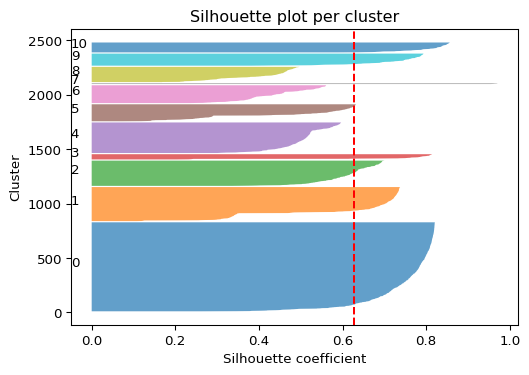

In [15]:
sil_vals = silhouette_samples(X_, cluster_labels)
y_lower = 10
plt.figure(figsize=(6,4))

for cid in np.unique(cluster_labels):
    c_sil = sil_vals[cluster_labels == cid]
    c_sil.sort()
    y_upper = y_lower + len(c_sil)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, c_sil, alpha=0.7)
    plt.text(-0.05, y_lower + len(c_sil)/2, str(cid))
    y_lower = y_upper + 10

plt.xlabel("Silhouette coefficient"); plt.ylabel("Cluster")
plt.axvline(sil_vals.mean(), color="red", linestyle="--")

plt.title("Silhouette plot per cluster")
plt.show()

## Feature Importance with Classification

In [16]:
t = DecisionTreeClassifier(max_depth=6, random_state=42)
feature_cols = [col for col in df.columns if col != "cluster"]
t.fit(df[feature_cols], kmeans.labels_)
feat_imp = pd.Series(t.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_imp

Surface Water Rights 2019-01-01    0.364726
Temp Max 1992-04-01                0.174617
Temp Min 1995-12-01                0.153676
Precipitation 1990-10-01           0.126311
PET 2018-04-01                     0.093978
                                     ...   
Temp Max 1987-04-01                0.000000
Temp Max 1987-03-01                0.000000
Temp Max 1987-02-01                0.000000
Temp Max 1987-01-01                0.000000
NDWI 2019-12                       0.000000
Length: 2294, dtype: float64

Because of the way the data is formatted, interpret the above as general groups of variables/times instead of specific dates. One specific column or date might represent an overall trend. For example, surface water rights in 2018 is not as important as the overall trend.

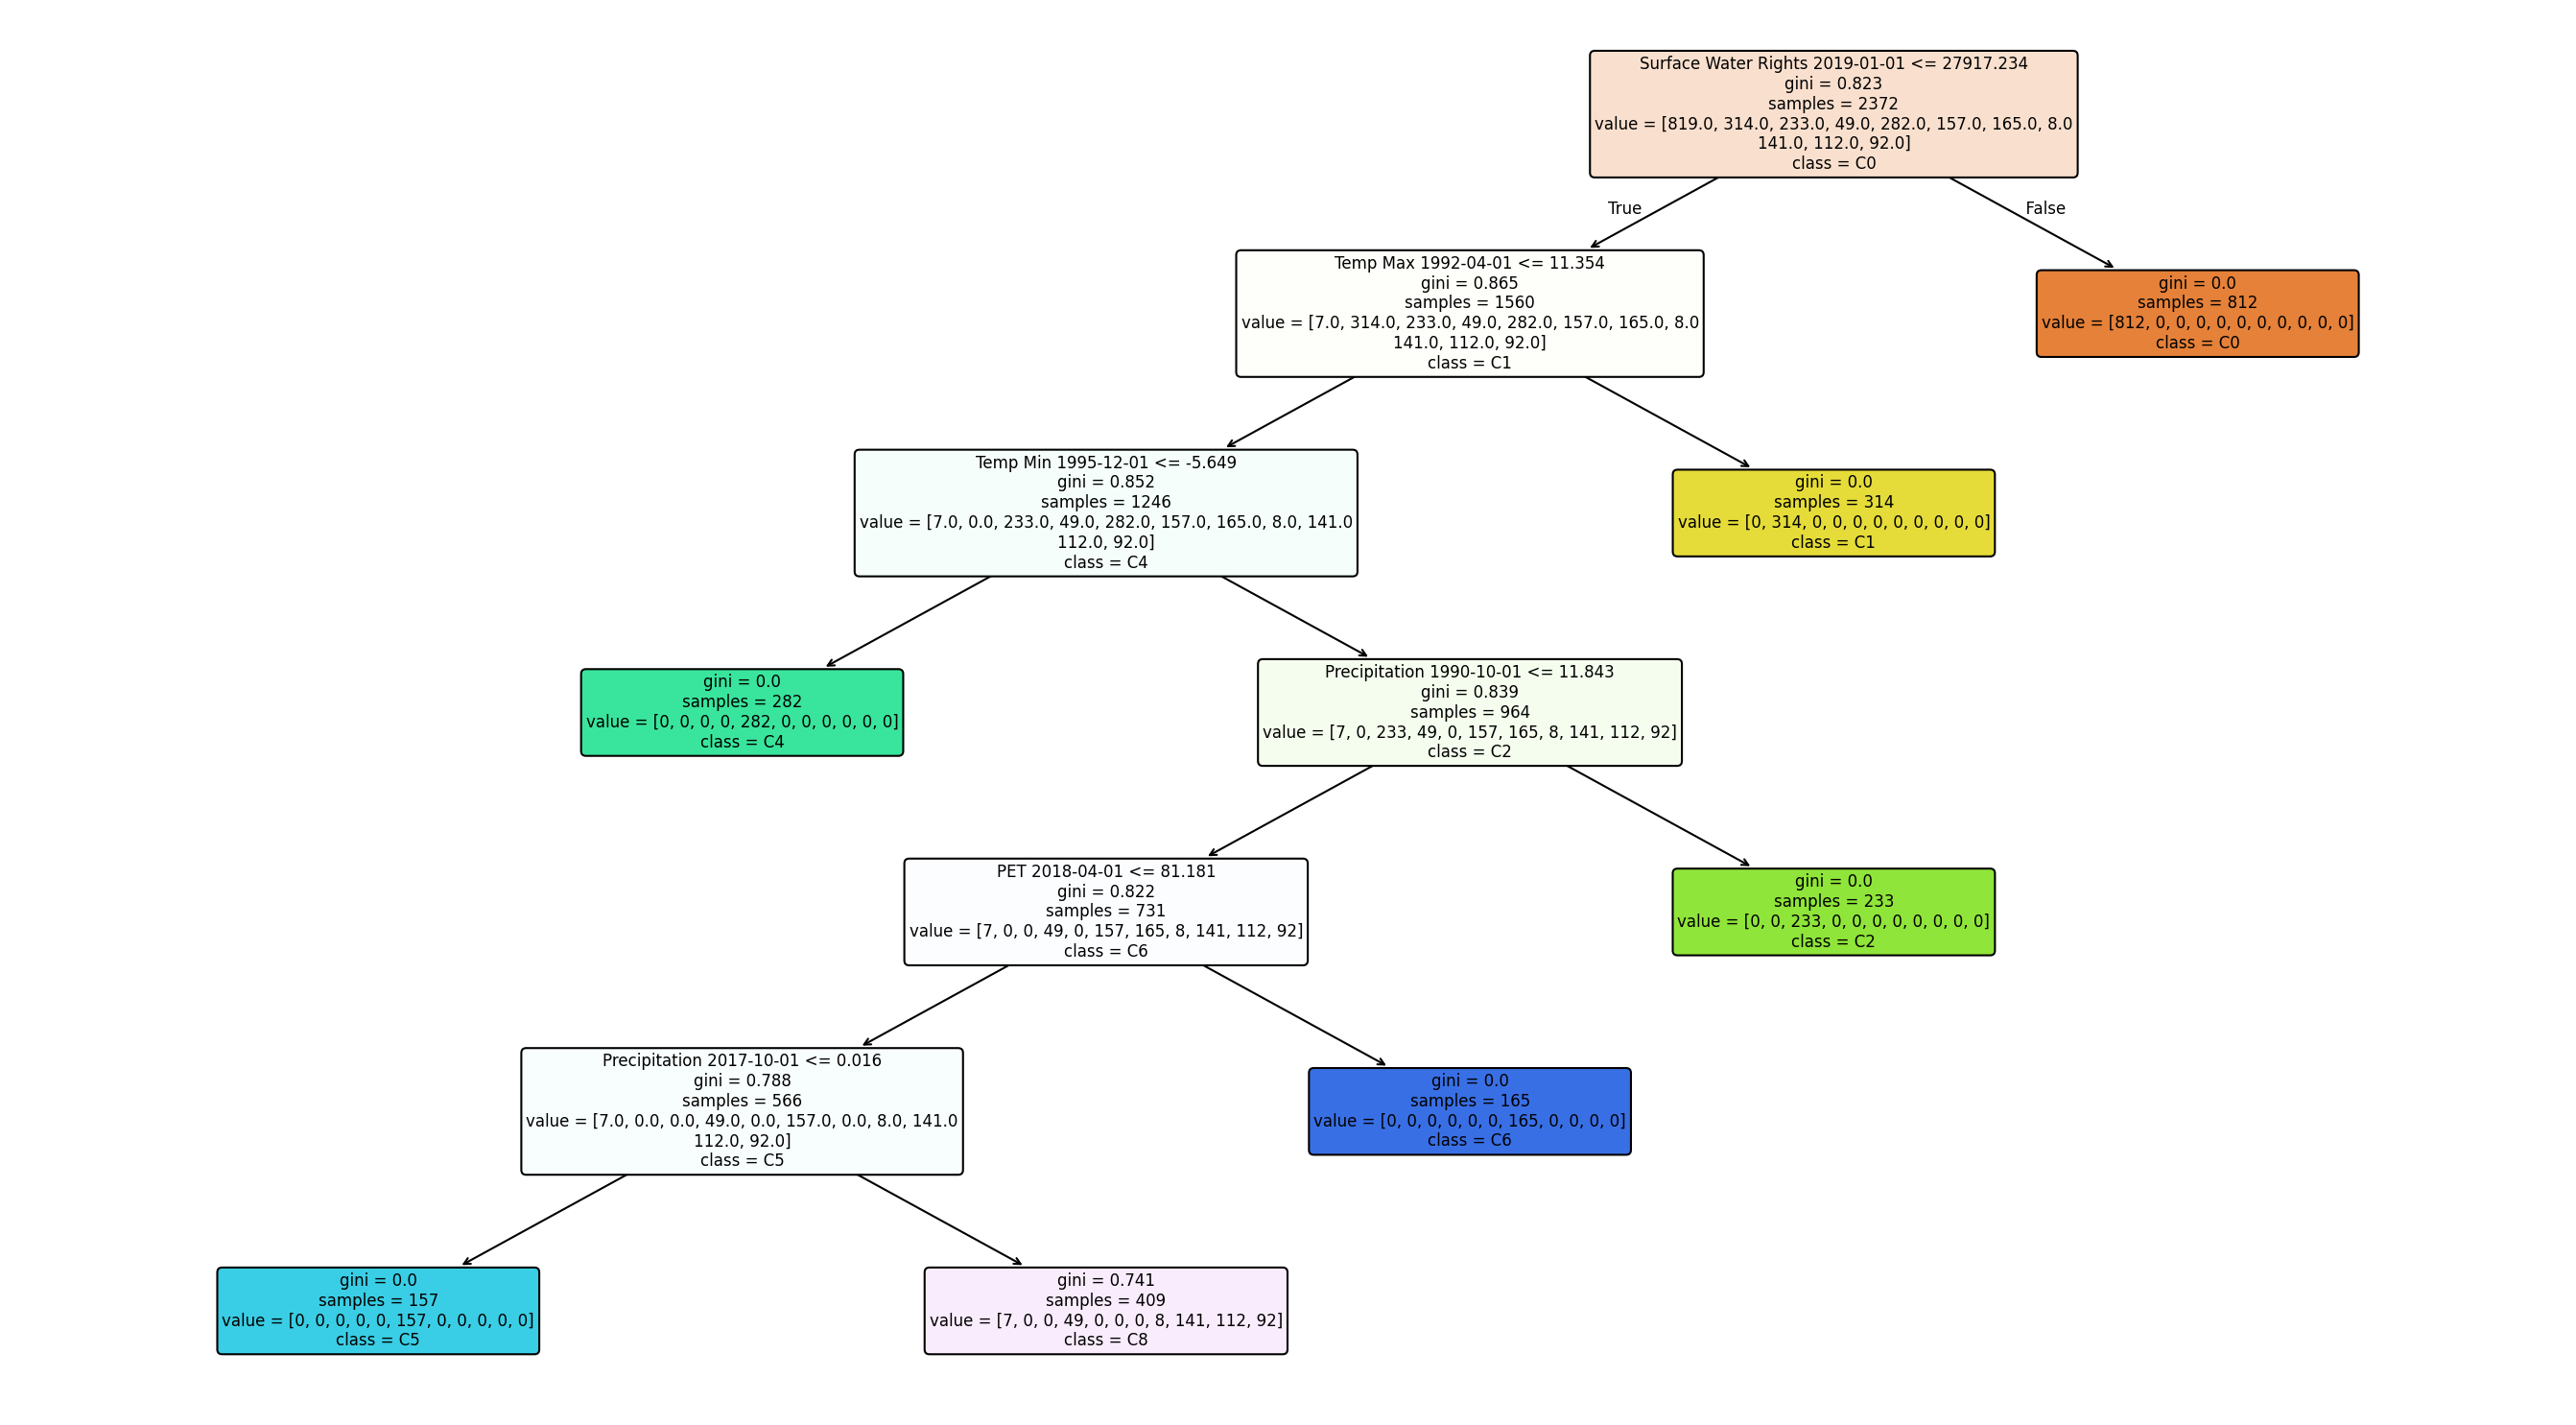

In [17]:
fig, ax = plt.subplots(figsize=(18, 10), dpi=150)
tree.plot_tree(
        t,
        feature_names=feature_cols,
        class_names=[f"C{i}" for i in sorted(set(df["cluster"]))],
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax)
plt.tight_layout()
# gini is a purity measurement, where gini=0 means this leaf contains all bofedales belonging to the cluster

## Data Visualizations

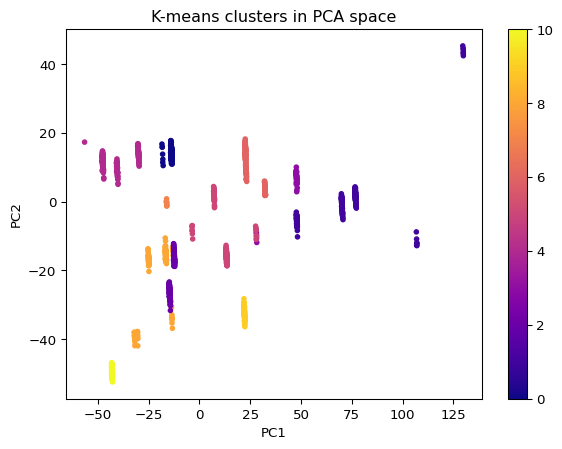

In [18]:
pca2 = PCA(n_components=2).fit_transform(X_)
plt.scatter(pca2[:,0], pca2[:,1], c=cluster_labels, s=10, cmap='plasma')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('K-means clusters in PCA space')
plt.colorbar()
plt.show()

In [19]:
HEX_0_10 = [
    "#88CCEE", "#CC6677", "#DDCC77", "#117733", "#332288",
    "#AA4499", "#44AA99", "#999933", "#882255", "#661100", "#6699CC"
]
COLOR_MAP_NUM = {i: HEX_0_10[i] for i in range(11)}
COLOR_MAP_STR = {str(i): HEX_0_10[i] for i in range(11)}

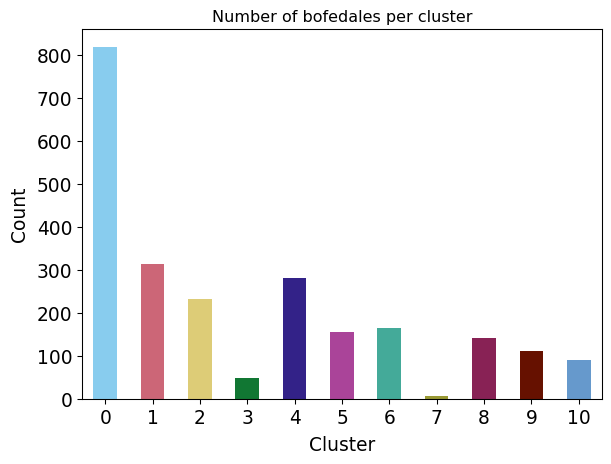

In [20]:
counts = (df["cluster"].dropna().astype(int)
          .value_counts().sort_index())

bar_colors = [COLOR_MAP_NUM[i] for i in counts.index]

ax = counts.plot.bar(color=bar_colors)
ax.set_xlabel("Cluster", fontsize=14, labelpad=6); ax.set_ylabel("Count", fontsize=14, labelpad=6)
ax.set_title("Number of bofedales per cluster")
ax.tick_params(axis='x', labelsize=14, rotation=0)
ax.tick_params(axis='y', labelsize=14)

In [21]:
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

gdf["size_for_plot"] = np.sqrt(gdf["Area_m2"].clip(lower=0))

sz = gdf["size_for_plot"].fillna(gdf["size_for_plot"].median())
if sz.min() == sz.max():
    radii = np.full(len(sz), 8.0)
else:
    radii = np.interp(sz, (sz.min(), sz.max()), (2.0, 20.0))

center = [gdf.geometry.y.mean(), gdf.geometry.x.mean()]
m = folium.Map(center, zoom_start=6, tiles="OpenStreetMap")

for (_, row), radius in zip(gdf.iterrows(), radii):
    key = row["cluster"]
    fill = COLOR_MAP_NUM.get(key, "#666666")
    folium.CircleMarker(
        location=(row.geometry.y, row.geometry.x),
        radius=float(radius),
        color="black",
        weight=0.3,
        fill=True,
        fill_opacity=0.6,
        fill_color=fill,
        popup=(f"Cluster {row.cluster}<br>Area = {row.Area_m2:,} m²"),
    ).add_to(m)

m

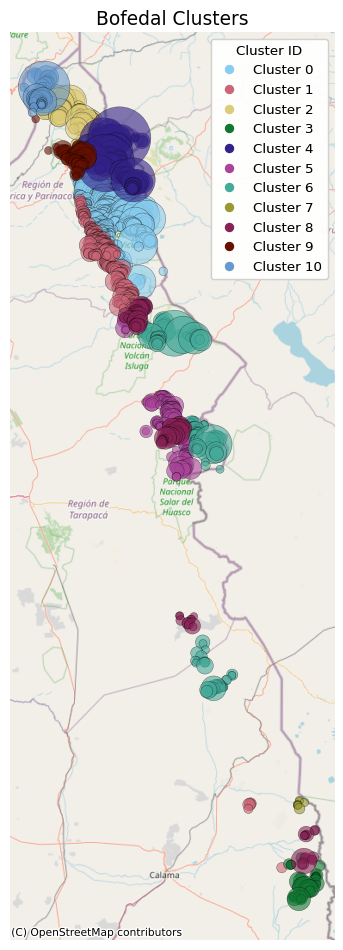

In [22]:
geometry = [Point(xy) for xy in zip(df.lon, df.lat)]

# 2. Build a GeoDataFrame:
gdf = gpd.GeoDataFrame(
    df.copy(), 
    geometry=geometry,
    crs="EPSG:4326"
)

gdf["size_for_plot"] = gdf["Area_m2"].apply(lambda a: (a**0.5))

# (b) Optionally multiply by a constant to get it into a sensible point-size range:
scale_factor = 0.5   # tweak until bubbles look neither too big nor too small
gdf["size_for_plot"] *= scale_factor

# 1. Reproject to WebMercator:
gdf_3857 = gdf.to_crs(epsg=3857)

# 2. Plot by cluster, using 'size_for_plot' as the marker size:
fig, ax = plt.subplots(figsize=(8, 10))

cmap = plt.get_cmap("tab10")  # up to 10 distinct colors

for i, cluster_id in enumerate(sorted(gdf_3857["cluster"].unique())):
    subset = gdf_3857[gdf_3857["cluster"] == cluster_id]
    
    # Scatter requires x = array of X coords, y = array of Y coords in Mercator:
    ax.scatter(
        subset.geometry.x,            # Web-Mercator X
        subset.geometry.y,            # Web-Mercator Y
        s=subset["size_for_plot"],    # marker area (in points²)
        c=[COLOR_MAP_NUM[cluster_id]],                  # a single color per cluster
        alpha=0.6,
        edgecolor="k",
        linewidth=0.3,
        label=f"Cluster {cluster_id}"
    )

# 3. Add a basemap beneath it. Choose whichever provider you like; here’s Stamen Terrain:
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    # zoom=6  # you can tweak zoom (0 is world, 5–7 is country‐level for Chile)
)

# 7.  Manually build a “Cluster ID” legend with uniform marker sizes
#     (so the legend doesn’t show giant/small bubbles).
cluster_handles = []
for idx, cluster_id in enumerate(sorted(gdf_3857["cluster"].unique())):
    cluster_handles.append(
        Line2D(
            [], [], 
            marker="o", 
            markersize=6,               # uniform size in points (note: diameter)
            color=COLOR_MAP_NUM.get(idx, "#666666"),
            linestyle="",
            label=f"Cluster {cluster_id}",
        )
    )

legend1 = ax.legend(handles=cluster_handles, title="Cluster ID", loc="upper right")
ax.add_artist(legend1)

ax.set_aspect('equal', adjustable='box')


# 4. Tidy up:
ax.set_axis_off()
ax.set_title("Bofedal Clusters", fontsize=14)
plt.tight_layout()

plt.show()

In [23]:
unit_mapping = {
    "Temp Min": "°C", 
    "Temp Max": "°C", 
    "Precipitation": "mm", 
    "Ground Water Rights": "L/s", 
    "Surface Water Rights": "L/s", 
    "PET": "mm", 
    "NDVI": "", 
    "NDWI": ""
}
vars_order = list(unit_mapping.keys())
default_var = vars_order[0]

# Optional guide lines
guide_lines = [
    # {"value": 0.0, "orientation": "h", "label": "Zero line", "color": "grey", "style": "dash", "width": 1},
]

long_parts = []
for var in vars_order:
    var_cols = [c for c in df.columns if c.startswith(f"{var} ")]
    if not var_cols:
        continue

    block = df[var_cols + ["cluster"]].copy()
    date_index = pd.to_datetime(
        [c.replace(f"{var} ", "") for c in var_cols], errors="raise"
    )
    block.columns = date_index.tolist() + ["cluster"]

    block = block.melt(id_vars="cluster", var_name="date", value_name="value")
    block["variable"] = var
    block["date"] = pd.to_datetime(block["date"], errors="raise")

    long_parts.append(block)

tidy = pd.concat(long_parts, ignore_index=True)

tidy["year"] = tidy["date"].dt.year
tidy_annual = (
    tidy
      .groupby(["cluster", "variable", "year"], as_index=False)
      .mean(numeric_only=True)
)

clusters = tidy_annual["cluster"].unique()

fig = go.Figure()
# build initial traces (sorted by year)
for clus in clusters:
    sub = (tidy_annual.query("cluster == @clus and variable == @default_var")
                      .sort_values("year"))
    fig.add_trace(go.Scatter(
        x=sub["year"].values,
        y=sub["value"].values,
        mode="lines",
        name=str(clus),
        line=dict(color=COLOR_MAP_NUM[clus], width=2)
    ))

buttons = []
for var in vars_order:
    xs = [(tidy_annual.query("cluster == @clus and variable == @var")
                      .sort_values("year")["year"].values)
          for clus in clusters]
    ys = [(tidy_annual.query("cluster == @clus and variable == @var")
                      .sort_values("year")["value"].values)
          for clus in clusters]

    label = var + (f" ({unit_mapping[var]})" if unit_mapping[var] else "")
    buttons.append(dict(
        label=var,
        method="update",
        args=[
            {"x": xs, "y": ys},                                  # ← update both
            {"title": f"Average {var} by Cluster",
             "yaxis": {"title": {"text": label}, "autorange": True}}
        ],
    ))

for ln in guide_lines:
    if ln["orientation"].lower().startswith("h"):
        fig.add_shape(
            type="line",
            x0=tidy_annual["year"].min(), x1=tidy_annual["year"].max(),
            y0=ln["value"], y1=ln["value"],
            line=dict(color=ln.get("color", "red"),
                      dash=ln.get("style", "dash"),
                      width=ln.get("width", 2))
        )
    else:
        fig.add_shape(
            type="line",
            y0=tidy_annual["value"].min(), y1=tidy_annual["value"].max(),
            x0=ln["value"], x1=ln["value"],
            line=dict(color=ln.get("color", "red"),
                      dash=ln.get("style", "dash"),
                      width=ln.get("width", 2))
        )

fig.update_layout(
    xaxis_title="Year",
    yaxis_title=f"{default_var}" + (f" ({unit_mapping[default_var]})" if unit_mapping[default_var] else ""),
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        buttons=buttons,
        x=0.0, xanchor="left",
        y=1.15, yanchor="top"
    )],
    legend_title_text="Cluster",
    height=500, width=900,
    margin=dict(t=90, r=20, l=60, b=50),
    font=dict(size=18)
)

fig

In [24]:
df_condensed = (
    df[['Area_m2', 'AUC', 'pct_prot', 'elev_mean_', 'elev_std_m',
        'n_wells', 'cluster', '1983_explr', '1983_explt', '1932_explt']]
      .rename(columns={
          'pct_prot': 'Percentage Protected Land (of total bofedal)',
          'Area_m2' : 'Area (in m²)',
          'AUC'     : 'Area of basin',
          'elev_mean_': 'Average Elevation (in m)',
          'elev_std_m': 'Elevation Standard Deviation (in m)',
          'n_wells'   : 'Number of wells (per catchment area)',
          '1983_explr': 'Mining Exploration Sites in 1983',
          '1983_explt': 'Mining Exploitation Sites in 1983',
          '1932_explt': 'Mining Exploitation Sites in 1932'
      })
)

agg = (df_condensed
       .groupby("cluster", as_index=False)
       .mean())
bar_colors = agg["cluster"].map(COLOR_MAP_NUM).fillna("#999999").tolist()

def make_trace(var):
    return go.Bar(
        x=agg["cluster"],
        y=agg[var],
        marker=dict(color=bar_colors, line=dict(color="black")),
        name=var
    )

vars_list   = list(agg.columns[1:])
default_var = vars_list[0]

fig = go.Figure(make_trace(default_var))

buttons = []
for i, var in enumerate(vars_list):
    buttons.append(
        dict(
            label  = var,
            method = "update",
            args   = [
                {"y": [agg[var]]},
                 # "marker.color": [palette[i % len(palette)]]},
                {
                  "yaxis": {"title": {"text": var}}
                }
            ]
        )
    )

fig.update_layout(
    title="",
    yaxis=dict(title=dict(text=default_var)),
    xaxis=dict(
        title="Cluster",
        type="category",
        categoryorder="array",
        categoryarray=agg["cluster"].tolist()
    ),
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        buttons=buttons,
        x=0.0, xanchor="left",
        y=1.15, yanchor="top"
    )],
    margin=dict(t=60, r=20, l=60, b=50),
    height=450, width=700,
    showlegend=False
)


fig

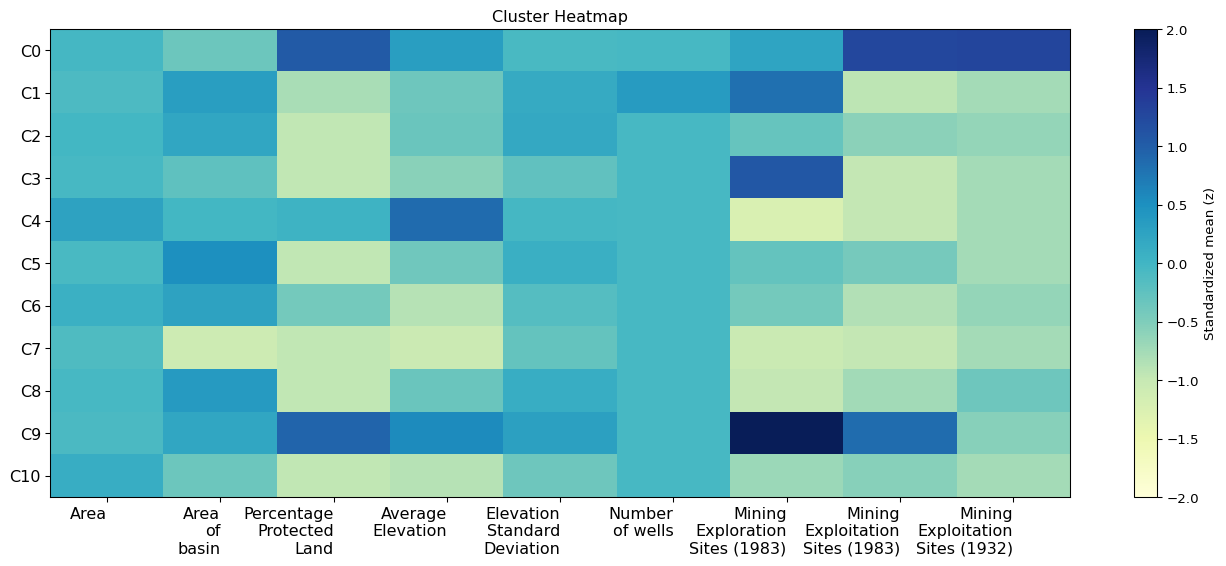

In [25]:
vars_ = ['Area_m2', 'AUC', 'pct_prot', 'elev_mean_', 'elev_std_m',
        'n_wells', '1983_explr', '1983_explt', '1932_explt']

# 1) standardize (z-score) across the whole dataset
Z = (df[vars_] - df[vars_].mean()) / df[vars_].std(ddof=0)
Z["cluster"] = df["cluster"]

# 2) per-cluster means
finger = Z.groupby("cluster")[vars_].mean().sort_index().rename(columns={
          'pct_prot': 'Percentage\nProtected\nLand',
          'Area_m2' : 'Area',
          'AUC'     : 'Area\nof\nbasin',
          'elev_mean_': 'Average\nElevation',
          'elev_std_m': 'Elevation\nStandard\nDeviation',
          'n_wells'   : 'Number\nof wells',
          '1983_explr': 'Mining\nExploration\nSites (1983)',
          '1983_explt': 'Mining\nExploitation\nSites (1983)',
          '1932_explt': 'Mining\nExploitation\nSites (1932)'
      })

# 3) heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(finger.values, aspect="auto", cmap="YlGnBu", vmin=-2, vmax=2)
ax.set_yticks(range(len(finger))); ax.set_yticklabels([f"C{c}" for c in finger.index])

ax.set_xticks(range(len(vars_))); ax.set_xticklabels(finger.columns, rotation=0, ha="right")
ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12)
cbar = plt.colorbar(im, ax=ax); cbar.set_label("Standardized mean (z)")
ax.set_title("Cluster Heatmap")
plt.tight_layout()
plt.show()